In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving nifty50_historical_data.csv to nifty50_historical_data (1).csv


In [ ]:
df = pd.read_csv("nifty50_historical_data.csv")

In [ ]:
df.head()

,Date,Ticker,Company_Name,Sector,Open,High,Low,Close,Volume,Dividend,...,Market_Cap,PE_Ratio,Forward_PE,PEG_Ratio,Price_to_Book,Dividend_Yield,EPS,Beta,52Week_High,52Week_Low
0,1999-01-01 00:00:00+05:30,AXISBANK.NS,Axis Bank Ltd.,Financials,2.198795,2.212041,2.139190,2.165681,337500,0.0,...,4257978515456,16.260086,13.534726,NaN,2.055485,0.07,84.28,0.313,1378.70,978.05
1,1999-01-01 00:00:00+05:30,BPCL.NS,Bharat Petroleum Corporation Ltd.,Energy,3.059547,3.083643,3.035450,3.073874,324744,0.0,...,1581385383936,6.329224,7.975497,NaN,1.658039,4.80,57.59,0.981,388.15,234.01
2,1999-01-01 00:00:00+05:30,BRITANNIA.NS,Britannia Industries Ltd.,FMCG,40.944134,40.974527,40.775792,40.845936,42000,0.0,...,1411608608768,60.977005,48.923096,NaN,37.810410,1.28,96.11,0.572,6336.00,4506.00
3,1999-01-01 00:00:00+05:30,CIPLA.NS,Cipla Ltd.,Pharma,19.149712,19.580167,19.006226,19.426748,108750,0.0,...,1069501579264,23.529411,23.371544,NaN,3.248832,0.98,56.27,0.042,1673.00,1281.70
4,1999-01-01 00:00:00+05:30,DRREDDY.NS,Dr. Reddy's Laboratories Ltd.,Pharma,21.000834,21.293348,21.000834,21.185806,2324000,0.0,...,1014151315456,17.929054,22.147236,NaN,2.723533,0.66,67.94,0.315,1379.70,1020.00


In [ ]:
print(df.columns)

Index(['Date', 'Ticker', 'Company_Name', 'Sector', 'Open', 'High', 'Low',
       'Close', 'Volume', 'Dividend', 'Stock_Split', 'Daily_Return',
       'Volatility_20D', 'MA_50', 'MA_200', 'Market_Cap', 'PE_Ratio',
       'Forward_PE', 'PEG_Ratio', 'Price_to_Book', 'Dividend_Yield', 'EPS',
       'Beta', '52Week_High', '52Week_Low'],
      dtype='object')


In [ ]:
df = df[df["Ticker"]=="RELIANCE.NS"]

In [ ]:
df.head()

,Date,Ticker,Company_Name,Sector,Open,High,Low,Close,Volume,Dividend,...,Market_Cap,PE_Ratio,Forward_PE,PEG_Ratio,Price_to_Book,Dividend_Yield,EPS,Beta,52Week_High,52Week_Low
13,1999-01-01 00:00:00+05:30,RELIANCE.NS,Reliance Industries Ltd.,Energy,6.041358,6.164702,6.021220,6.152117,92105588,0.0,...,18883211689984,22.674683,21.09794,NaN,2.152996,0.39,61.54,0.307,1611.8,1114.85
33,1999-01-04 00:00:00+05:30,RELIANCE.NS,Reliance Industries Ltd.,Energy,6.192392,6.305667,6.159668,6.217565,126563432,0.0,...,18883211689984,22.674683,21.09794,NaN,2.152996,0.39,61.54,0.307,1611.8,1114.85
53,1999-01-05 00:00:00+05:30,RELIANCE.NS,Reliance Industries Ltd.,Energy,6.230149,6.242736,6.157149,6.192391,86519930,0.0,...,18883211689984,22.674683,21.09794,NaN,2.152996,0.39,61.54,0.307,1611.8,1114.85
73,1999-01-06 00:00:00+05:30,RELIANCE.NS,Reliance Industries Ltd.,Energy,6.305668,6.325806,6.227635,6.242738,99531425,0.0,...,18883211689984,22.674683,21.09794,NaN,2.152996,0.39,61.54,0.307,1611.8,1114.85
93,1999-01-07 00:00:00+05:30,RELIANCE.NS,Reliance Industries Ltd.,Energy,6.265392,6.632908,6.257841,6.544805,237430025,0.0,...,18883211689984,22.674683,21.09794,NaN,2.152996,0.39,61.54,0.307,1611.8,1114.85


In [ ]:
df = df[["Date","Close"]]

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df = df.sort_values("Date")

In [ ]:
df.reset_index(drop=True,inplace=True)

In [ ]:
df.head()

,Date,Close
0,1999-01-01 00:00:00+05:30,6.152117
1,1999-01-04 00:00:00+05:30,6.217565
2,1999-01-05 00:00:00+05:30,6.192391
3,1999-01-06 00:00:00+05:30,6.242738
4,1999-01-07 00:00:00+05:30,6.544805


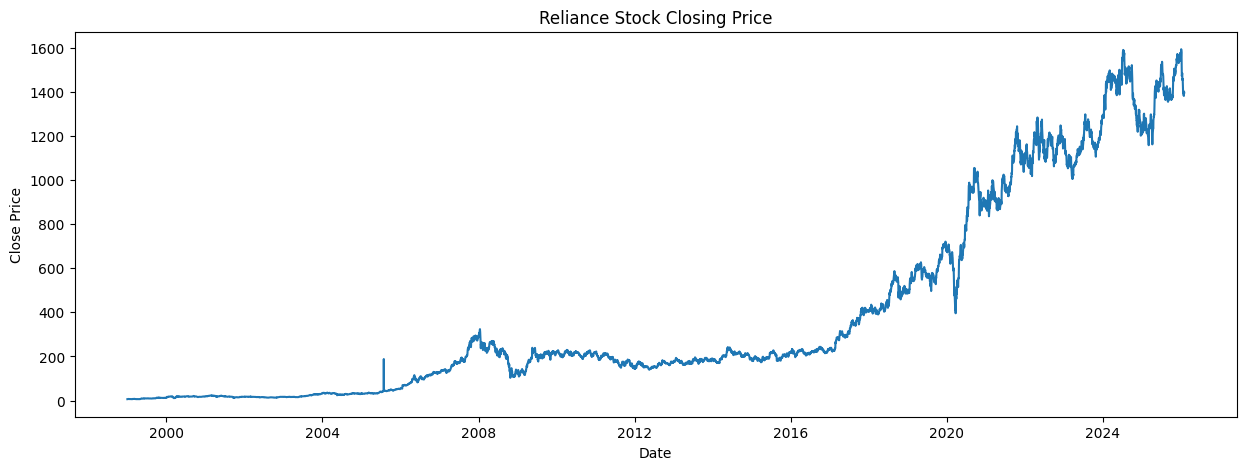

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"],df["Close"])

plt.title("Reliance Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

In [ ]:
close_price = df["Close"].values.reshape(-1,1)

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))

In [ ]:
scaled_data = scaler.fit_transform(close_price)

In [ ]:
scaled_data

array([[1.55502824e-04],
       [1.96758515e-04],
       [1.80890340e-04],
       ...,
       [8.76701487e-01],
       [8.73108465e-01],
       [8.75882065e-01]])

In [ ]:
seq_length = 10

In [ ]:
x = []
y = []

In [ ]:
for i in range(len(scaled_data)-seq_length):
    x.append(scaled_data[i:i+seq_length])
    y.append(scaled_data[i+seq_length])

In [ ]:
x = np.array(x)

In [ ]:
y = np.array(y)

In [ ]:
print("Shape of X :", x.shape)

Shape of X : (6757, 10, 1)


In [ ]:
print("Shape of y :", y.shape)

Shape of y : (6757, 1)


In [ ]:
train_size = int(len(x)*0.8)

In [ ]:
X_train = x[:train_size]
X_test = x[train_size:]

In [ ]:
y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
print("Training samples :", X_train.shape)

Training samples : (5405, 10, 1)


In [ ]:
print("Testing samples :", X_test.shape)

Testing samples : (1352, 10, 1)


In [ ]:
print(X_train.shape)
print(X_test.shape)

(5405, 10, 1)
(1352, 10, 1)


In [ ]:
print(y_train.shape)
print(y_test.shape)

(5405, 1)
(1352, 1)


In [ ]:
model = Sequential()

In [ ]:
model.add(SimpleRNN(
    units=50,
    activation='tanh',
    input_shape=(seq_length,1)
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.add(Dense(1))

In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=70,
    batch_size=32,
    validation_data=(X_test,y_test),
    verbose=1
)

Epoch 1/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8.7968e-04 - val_loss: 0.0121
Epoch 2/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4160e-05 - val_loss: 0.0056
Epoch 3/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.3770e-05 - val_loss: 0.0033
Epoch 4/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.3407e-05 - val_loss: 8.2545e-04
Epoch 5/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.7142e-05 - val_loss: 2.8782e-04
Epoch 6/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.1339e-05 - val_loss: 7.4939e-04
Epoch 7/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.6507e-05 - val_loss: 2.5691e-04
Epoch 8/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.4129e-05 - val_loss: 3.3358e-04
Epoch 9/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.2946e-05 - val_loss: 8.0204e-04
Epoch 10/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.3030e-05 - val_loss: 2.4629e-04
Epoch 11/70
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.5717e-05

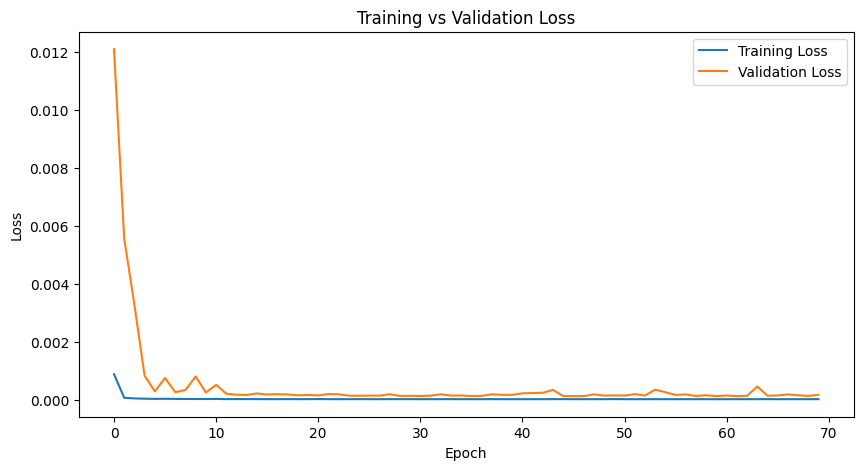

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
y_pred = model.predict(X_test)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
y_test_actual = scaler.inverse_transform(y_test)

In [ ]:
y_pred_actual = scaler.inverse_transform(y_pred)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [ ]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

In [ ]:
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 15.830489164273414
Root Mean Squared Error (RMSE): 20.647815960804138


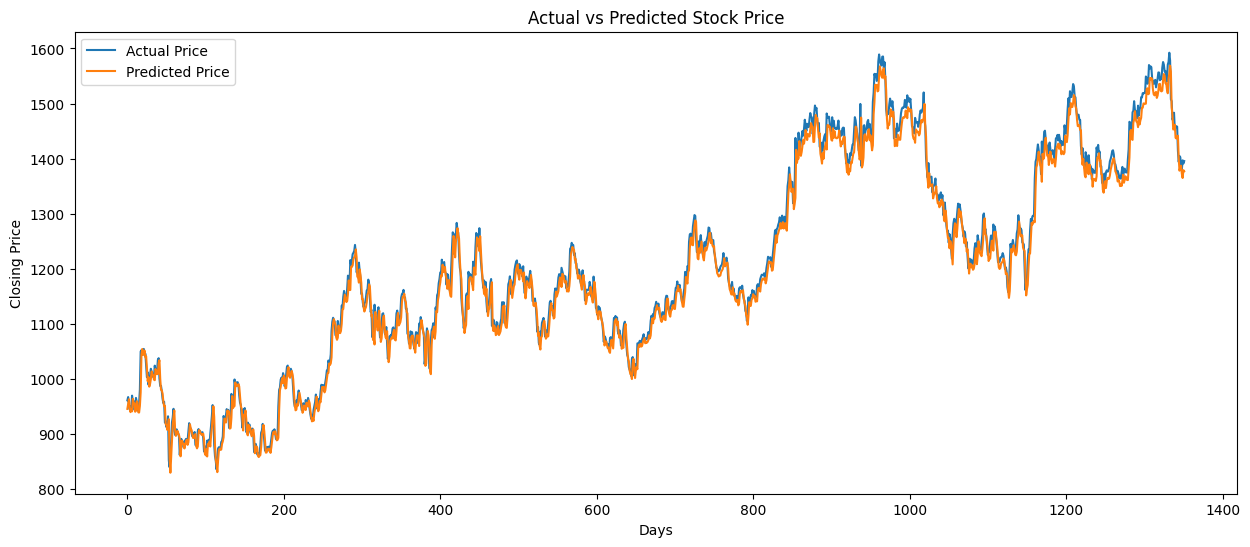

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(y_pred_actual, label="Predicted Price")

plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Days")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

In [ ]:
last_sequence = scaled_data[-seq_length:]

last_sequence = last_sequence.reshape(1, seq_length, 1)

next_price_scaled = model.predict(last_sequence)

next_price = scaler.inverse_transform(next_price_scaled)

print("Predicted Next Day Closing Price :", next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Next Day Closing Price : 1381.3142


In [ ]:
model.save("Stock_RNN_Model.keras")

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files

files.download("Stock_RNN_Model.keras")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>